# 01 — Understand the synthetic trading book

Identify what the bank holds before measuring market risk.

A trading book is the collection of positions whose values change with market prices. Every position here is synthetic. Desks and sub-portfolios keep rates, credit, equity, foreign-exchange, commodity and residual-risk positions understandable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

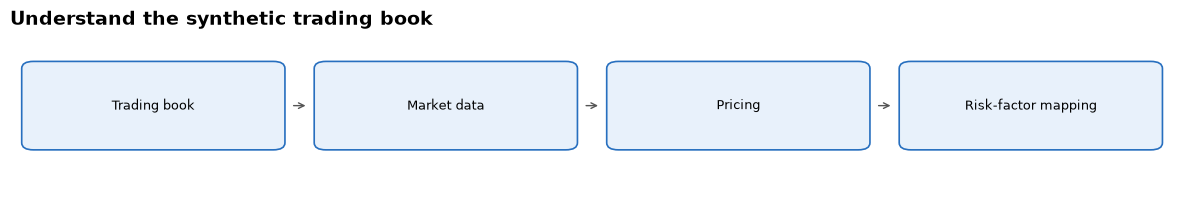

In [2]:
draw_flow(['Trading book', 'Market data', 'Pricing', 'Risk-factor mapping'],'Understand the synthetic trading book',wrap_after=4)

This step checks economic direction, notional, currency, maturity and product type. It does not calculate capital.

$$\text{Position}=\text{quantity or notional}\times\text{long/short direction}$$

In [3]:
trades=pd.read_csv(RUN/'01_trades.csv')
shown=trades[['trade_id','desk','sub_portfolio','instrument_type','product_form','currency',
              'notional','long_short','underlying','maturity_years','is_synthetic']].copy()
shown['notional']=shown['notional']/INR_CRORE
shown=shown.rename(columns={'notional':'Notional in trade currency (crore)'})
display(shown)
portfolio_map=trades.groupby(['desk','product_form']).size().unstack(fill_value=0)
display(portfolio_map)

,trade_id,desk,sub_portfolio,instrument_type,product_form,currency,Notional in trade currency (crore),long_short,underlying,maturity_years,is_synthetic
0,R01,Rates,INR Government,BOND,cash,INR,10.0000,long,INR_GSEC,2.0000,1
1,R02,Rates,INR Government,BOND,cash,INR,15.0000,long,INR_GSEC,5.0000,1
2,R03,Rates,INR Government,BOND,cash,INR,12.0000,short,INR_GSEC,10.0000,1
3,R04,Rates,Foreign Government,BOND,cash,USD,0.2000,long,USD_TREASURY,5.0000,1
4,R05,Rates,Foreign Government,BOND,cash,EUR,0.1800,long,EUR_BUND,10.0000,1
5,R06,Rates,Swaps,IRS,derivative,INR,20.0000,short,INR_OIS,5.0000,1
6,R07,Rates,Swaps,IRS,derivative,USD,0.3000,long,USD_OIS,10.0000,1
7,R08,Rates,Money Market,FRA,derivative,INR,10.0000,long,INR_OIS,0.5000,1
8,R09,Rates,Options,SWAPTION,derivative,INR,15.0000,long,INR_OIS,5.0000,1
9,R10,Rates,Options,SWAPTION,derivative,USD,0.2500,long,USD_OIS,10.0000,1


product_form,cash,derivative
desk,,
Commodity,0,7
Credit,6,6
Equity,5,5
FX,0,5
Rates,6,6
Residual Risk,0,2


The visual below uses the calculated rows shown above.

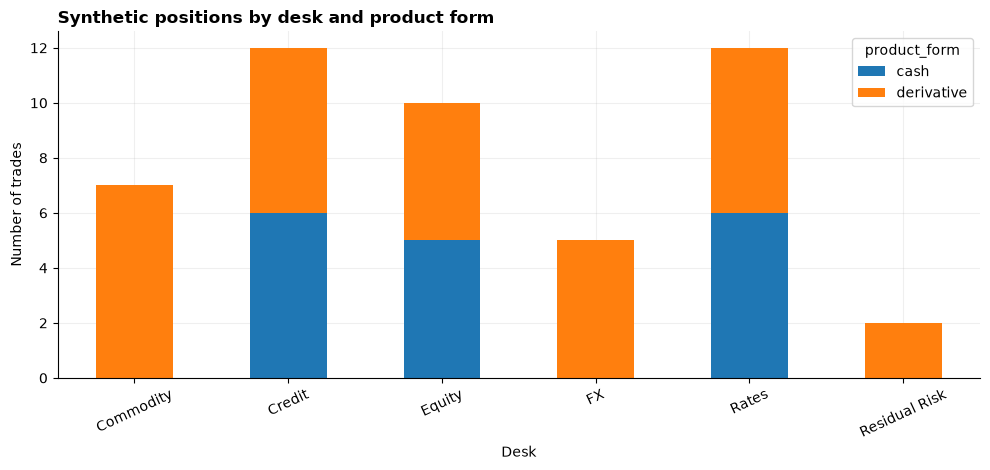

In [4]:
portfolio_map.plot(kind='bar',stacked=True)
plt.title('Synthetic positions by desk and product form',loc='left',weight='bold')
plt.ylabel('Number of trades'); plt.xlabel('Desk'); plt.xticks(rotation=25)
plt.tight_layout(); plt.show()

The output is the complete economic inventory that will be priced next.